BIAS VALUE COUNTS: 
bias
0.0    19033
1.0    10346
Name: count, dtype: int64
count    29379.000000
mean       114.653120
std         57.510415
min          4.000000
25%         69.000000
50%        108.000000
75%        148.000000
max        250.000000
Name: text_length, dtype: float64


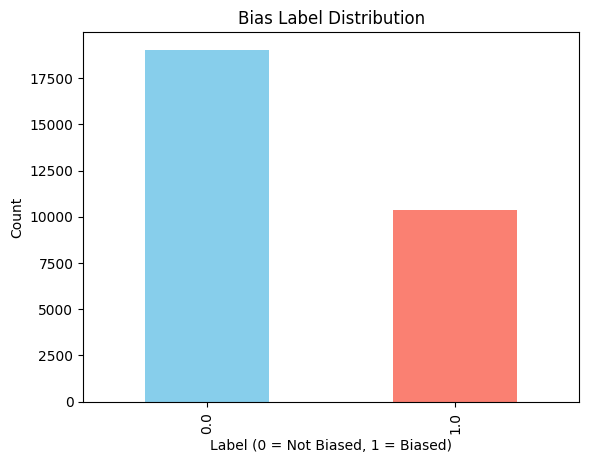

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load data "all_data.csv"
all_data = pd.read_csv('all_data.csv')

# Count bias labels
print("BIAS VALUE COUNTS: ")
print(all_data['bias'].value_counts())
all_data['text_length'] = all_data['text'].astype(str).apply(len)
print(all_data['text_length'].describe())

all_data['bias'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Bias Label Distribution")
plt.xlabel("Label (0 = Not Biased, 1 = Biased)")
plt.ylabel("Count")
plt.show()

In [2]:

# Split data into train and test
from sklearn.model_selection import train_test_split

X = all_data[['text']]
y = all_data['bias']

# First split: 60% train, 40% temporary (for val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y  # This ensures balanced splits
)

# Second split: Split temp into 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val set size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Verify class distribution
print("\nClass distribution:")
print(f"Train - 0: {sum(y_train==0.0)}, 1: {sum(y_train==1.0)}")
print(f"Val   - 0: {sum(y_val==0.0)}, 1: {sum(y_val==1.0)}")
print(f"Test  - 0: {sum(y_test==0.0)}, 1: {sum(y_test==1.0)}")


Train set size: 17627 (60.0%)
Val set size: 5876 (20.0%)
Test set size: 5876 (20.0%)

Class distribution:
Train - 0: 11420, 1: 6207
Val   - 0: 3806, 1: 2070
Test  - 0: 3807, 1: 2069


In [3]:
X_train.head()

,text
24717,So stop being sexist towards women. Don't be t...
16963,Notice the difference in the natural waistline...
20341,"fuck jeez, why do we hold these people up agai..."
16367,You advocated for your girlfriend to cuck you ...
23818,I would love to suck her tits


In [4]:
y_train.head()

24717    0.0
16963    1.0
20341    0.0
16367    0.0
23818    0.0
Name: bias, dtype: float64

Tokenization with HuggingFace

In [5]:
from transformers import AutoTokenizer
from datasets import Dataset

# read data as Huggingface "Dataset" type
train_df = pd.DataFrame({"text": X_train["text"], "labels": y_train.astype(int).values})
test_df  = pd.DataFrame({"text": X_test["text"],  "labels": y_test.astype(int).values})

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
test_dataset  = Dataset.from_pandas(test_df, preserve_index=False)

# Tokenize the text
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128) # usually text is about 128 long

tokenized_train = train_dataset.map(tokenize_fn, batched=True)
tokenized_test = test_dataset.map(tokenize_fn, batched=True)

tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

/Users/marcinzarkowski/Code/Meta1A/train/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 5876/5876 [00:00<00:00, 40412.44 examples/s]


*Train*

In [ ]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import BertForSequenceClassification, TrainingArguments, RobertaForSequenceClassification
import torch
from torch.nn import CrossEntropyLoss

# Define metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# Load model
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

# Custom Trainer with class weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply class weights: [weight for class 0, weight for class 1]
        class_weights = torch.tensor([0.5, 1.0]).to(logits.device)
        loss_fct = CrossEntropyLoss(weight=class_weights)

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

EPOCHS = 2

training_args = TrainingArguments(
    output_dir="",
    eval_strategy="epoch",   # evaluate at the end of each epoch
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_strategy="no",
    report_to=[]
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

trainer.train()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/marcinzarkowski/Code/Meta1A/train/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.372646,0.830497,0.716768,0.857419,0.780810
2,No log,0.390600,0.852110,0.765252,0.836636,0.799353


/Users/marcinzarkowski/Code/Meta1A/train/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=2204, training_loss=0.3988331761853448, metrics={'train_runtime': 763.5069, 'train_samples_per_second': 46.174, 'train_steps_per_second': 2.887, 'total_flos': 2318929286415360.0, 'train_loss': 0.3988331761853448, 'epoch': 2.0})

/Users/marcinzarkowski/Code/Meta1A/train/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


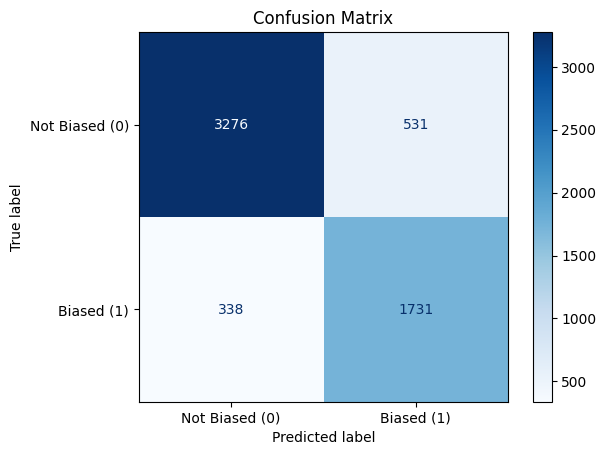

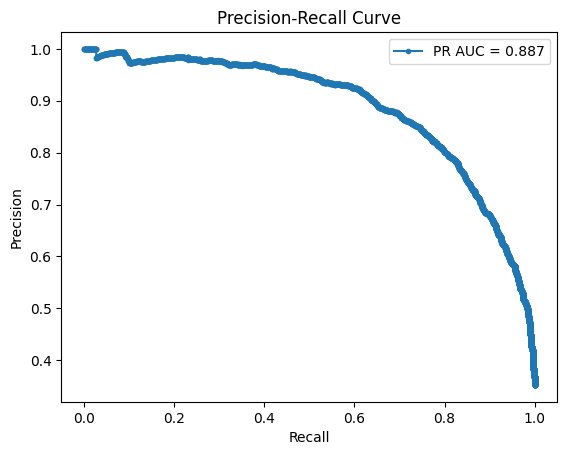

In [8]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Put model in evaluation mode
model.eval()

# Collect predictions and labels
preds_output = trainer.predict(tokenized_test)
preds = preds_output.predictions.argmax(axis=1)
labels = preds_output.label_ids

# Confusion Matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Biased (0)", "Biased (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Precision-Recall Curve
probs = torch.softmax(torch.tensor(preds_output.predictions), dim=1)[:,1].numpy()  # probability for class 1
precision, recall, thresholds = precision_recall_curve(labels, probs)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [9]:
import torch

# Example list of sentences to classify
texts_to_test = [
    "black people are quite lazy.",
    "people are lazy",
    "This country sucks",
    "Chess is the best board game",
    "chess is the worst board game",
    "This is a completely neutral sentence.",
    "I think this is unfair and biased.",
]

# Tokenize the input texts using the same tokenizer function
def tokenize_texts(texts, tokenizer, max_length=128):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

# Tokenize
inputs = tokenize_texts(texts_to_test, tokenizer)

# Move inputs to same device as the model (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}

# Put model in eval mode
model.eval()

# Make predictions
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)  # 0 = Not Biased, 1 = Biased
    print(predictions)

# Print results
for text, pred in zip(texts_to_test, predictions):
    label = "Biased" if pred.item() == 1 else "Not Biased"
    print(f"Text: {text}\nPrediction: {label}\n")


tensor([1, 1, 0, 0, 1, 0, 0])
Text: black people are quite lazy.
Prediction: Biased

Text: people are lazy
Prediction: Biased

Text: This country sucks
Prediction: Not Biased

Text: Chess is the best board game
Prediction: Not Biased

Text: chess is the worst board game
Prediction: Biased

Text: This is a completely neutral sentence.
Prediction: Not Biased

Text: I think this is unfair and biased.
Prediction: Not Biased



In [ ]:
# ==========================
# 8. Save Model
# ==========================
save_dir = "models/roberta_bias_model_final"
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

('models/roberta_bias_model_final/tokenizer_config.json',
 'models/roberta_bias_model_final/special_tokens_map.json',
 'models/roberta_bias_model_final/vocab.json',
 'models/roberta_bias_model_final/merges.txt',
 'models/roberta_bias_model_final/added_tokens.json',
 'models/roberta_bias_model_final/tokenizer.json')

In [ ]:
#Make an env file with HF_TOKEN value being your token from Huggging Face to upload this model to Hugging Face.
import os
from huggingface_hub import HfApi
from dotenv import load_dotenv
load_dotenv()

hf_token = os.getenv("HF_TOKEN")
api = HfApi(token=hf_token)

api.upload_folder(
    folder_path="models/roberta_bias_model_final",
    repo_id="Meta1A/roberta-v1",
    commit_message="Upload trained bias classification model"
)

: 

In [ ]:
# clean up local folder with models after uploading to Hugging Face repo
! rm -rf models

: 